# FRC 2026 – Autonomous Win Impact Analysis

**Objective:** Analyze how winning autonomous correlates with match wins across all official 2026 FRC events (regular season, DCMP, and CMP). Calculates win percentages, winning auto score distributions, and auto win margin distributions for qualification matches, playoff matches, and all matches combined — broken down by week and overall.

**Foul Adjustment:** Match winners are determined after removing foul points from both alliances' total scores. Matches that become ties after foul removal (and actual ties) are excluded from the analysis. Auto ties (both alliances scored equal auto points) are also excluded.

**Data Source:** [The Blue Alliance API v3](https://www.thebluealliance.com/apidocs/v3)

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from dotenv import load_dotenv

load_dotenv()

True

## Configuration

In [2]:
# ── USER CONFIG ──────────────────────────────────────────────────────────────
TBA_API_KEY  = os.environ["TBA_API_KEY"]  # Loaded from .env file
CURRENT_YEAR = 2026
OFFICIAL_EVENT_TYPES = {0, 1, 2, 3, 4, 5, 6}  # Regional, District, DCMP, CMP, FOC
# ─────────────────────────────────────────────────────────────────────────────

BASE_URL = "https://www.thebluealliance.com/api/v3"
HEADERS  = {"X-TBA-Auth-Key": TBA_API_KEY}


def tba_get(endpoint: str, retries: int = 3, backoff: float = 2.0):
    """GET wrapper with basic retry / rate-limit handling."""
    url = f"{BASE_URL}{endpoint}"
    for attempt in range(retries):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=10)
            if resp.status_code == 200:
                return resp.json()
            elif resp.status_code == 429:
                wait = backoff * (attempt + 1)
                print(f"Rate limited – waiting {wait}s before retry...")
                time.sleep(wait)
            else:
                print(f"HTTP {resp.status_code} for {url}")
                return None
        except requests.exceptions.RequestException as e:
            print(f"Request error ({attempt+1}/{retries}): {e}")
            time.sleep(backoff)
    return None

print("Configuration loaded.")

Configuration loaded.


## Step 1 – Fetch All Official 2026 Events

In [3]:
all_events = tba_get(f"/events/{CURRENT_YEAR}")

if not all_events:
    raise RuntimeError("Failed to fetch events list.")

# Keep only official season events (excludes preseason & offseason)
events = [
    e for e in all_events
    if e.get("event_type", 99) in OFFICIAL_EVENT_TYPES
       and (e.get("week") is not None or e.get("event_type") in {3, 4})
]

# CMP events have week=None in TBA – assign them the next week after the last regular week
max_regular_week = max((e["week"] for e in events if e.get("week") is not None), default=-1)
CMP_WEEK = max_regular_week + 1
for e in events:
    if e.get("week") is None:
        e["week"] = CMP_WEEK

# Build human-readable week labels; detect CMP / DCMP weeks
week_event_types: dict[int, set[int]] = {}
for e in events:
    week_event_types.setdefault(e["week"], set()).add(e.get("event_type", 0))

week_labels: dict[int, str] = {}
for w in sorted(week_event_types):
    if week_event_types[w] & {3, 4}:
        week_labels[w] = f"CMP (Wk {w + 1})"
    elif week_event_types[w] & {2, 5}:
        week_labels[w] = f"DCMP (Wk {w + 1})"
    else:
        week_labels[w] = f"Week {w + 1}"

print(f"Found {len(events)} official events across {len(week_labels)} weeks in {CURRENT_YEAR}.")
for w in sorted(week_labels):
    count = sum(1 for e in events if e["week"] == w)
    print(f"  {week_labels[w]}: {count} events")
print()
for e in events[:10]:
    print(f"  {e['key']}: {e['name']} ({week_labels[e['week']]})")
if len(events) > 10:
    print(f"  ... and {len(events) - 10} more")

Found 215 official events across 8 weeks in 2026.
  Week 1: 30 events
  Week 2: 34 events
  Week 3: 39 events
  DCMP (Wk 4): 37 events
  Week 5: 21 events
  DCMP (Wk 6): 25 events
  DCMP (Wk 7): 20 events
  CMP (Wk 8): 9 events

  2026alhu: Rocket City Regional (DCMP (Wk 6))
  2026arc: Archimedes Division (CMP (Wk 8))
  2026arli: Arkansas Regional (Week 3)
  2026ausc: Southern Cross Regional (Week 2)
  2026azfg: Arizona North Regional (Week 2)
  2026bcvi: Canadian Pacific Regional (Week 1)
  2026brba: Regional Brazil - Festival SESI de Educação (Week 1)
  2026brsp: Regional Brazil - SESI OSASCO (Week 2)
  2026caasv: CA District Aerospace Valley Event (Week 5)
  2026cacac: CA District Contra Costa Event (Week 5)
  ... and 205 more


## Step 2 – Discover Score Breakdown Fields

Inspect the actual field names available in the 2026 match score breakdown before extracting data.

In [4]:
import json

# Fetch a sample match and print the full raw score breakdown (including nested objects)
for event in events:
    matches = tba_get(f"/event/{event['key']}/matches")
    if not matches:
        continue
    for match in matches:
        sb = match.get("score_breakdown")
        if sb and sb.get("red"):
            print(f"Sample match: {match['key']}\n")
            print("Full red alliance score breakdown:")
            print(json.dumps(sb["red"], indent=2))
            break
    else:
        continue
    break

Sample match: 2026ausc_f1m1

Full red alliance score breakdown:
{
  "adjustPoints": 0,
  "autoTowerPoints": 0,
  "autoTowerRobot1": "None",
  "autoTowerRobot2": "None",
  "autoTowerRobot3": "None",
  "endGameTowerPoints": 0,
  "endGameTowerRobot1": "None",
  "endGameTowerRobot2": "None",
  "endGameTowerRobot3": "None",
  "energizedAchieved": false,
  "foulPoints": 5,
  "g206Penalty": false,
  "hubScore": {
    "autoCount": 77,
    "autoPoints": 77,
    "endgameCount": 65,
    "endgamePoints": 65,
    "shift1Count": 0,
    "shift1Points": 0,
    "shift2Count": 105,
    "shift2Points": 105,
    "shift3Count": 0,
    "shift3Points": 0,
    "shift4Count": 89,
    "shift4Points": 89,
    "teleopCount": 283,
    "teleopPoints": 283,
    "totalCount": 360,
    "totalPoints": 360,
    "transitionCount": 24,
    "transitionPoints": 24,
    "uncounted": 4
  },
  "majorFoulCount": 0,
  "minorFoulCount": 0,
  "penalties": "None",
  "rp": 0,
  "superchargedAchieved": false,
  "totalAutoPoints": 77,

In [5]:
records = []
total_events = len(events)
event_week_map = {e["key"]: e["week"] for e in events}

for idx, event in enumerate(events, start=1):
    event_key = event["key"]
    if idx % 10 == 0 or idx == total_events:
        print(f"  Fetching matches for event {idx}/{total_events}: {event_key}")

    matches = tba_get(f"/event/{event_key}/matches")
    if not matches:
        continue

    for match in matches:
        # Skip matches without score breakdowns (unplayed matches)
        sb = match.get("score_breakdown")
        if not sb or not sb.get("red") or not sb.get("blue"):
            continue

        # autoCount and autoPoints live inside the nested hubScore object
        red_hub  = sb["red"].get("hubScore") or {}
        blue_hub = sb["blue"].get("hubScore") or {}

        red_auto  = red_hub.get("autoPoints")   # auto fuel points (excludes tower)
        blue_auto = blue_hub.get("autoPoints")
        red_auto_count  = red_hub.get("autoCount")   # raw fuel count (for reference)
        blue_auto_count = blue_hub.get("autoCount")

        if red_auto is None or blue_auto is None:
            continue

        red_total  = match["alliances"]["red"]["score"]
        blue_total = match["alliances"]["blue"]["score"]

        # Remove foul points to get foul-adjusted totals
        red_foul_pts  = sb["red"].get("foulPoints", 0)
        blue_foul_pts = sb["blue"].get("foulPoints", 0)
        red_adj  = red_total - red_foul_pts
        blue_adj = blue_total - blue_foul_pts

        # Determine winner from foul-adjusted scores; skip ties
        if red_adj > blue_adj:
            winning_alliance = "red"
        elif blue_adj > red_adj:
            winning_alliance = "blue"
        else:
            continue  # tie after foul removal – excluded

        # Determine who won auto fuel points; skip auto ties
        if red_auto > blue_auto:
            auto_winner = "red"
        elif blue_auto > red_auto:
            auto_winner = "blue"
        else:
            continue  # auto tie – excluded

        # comp_level: qm = quals, qf/sf/f = playoffs
        comp_level = match.get("comp_level", "")
        match_type = "qual" if comp_level == "qm" else "playoff"

        records.append({
            "event_key":              event_key,
            "match_key":              match["key"],
            "match_type":             match_type,
            "week":                   event_week_map[event_key],
            "red_auto_fuel_points":   red_auto,
            "blue_auto_fuel_points":  blue_auto,
            "red_auto_fuel_count":    red_auto_count,
            "blue_auto_fuel_count":   blue_auto_count,
            "red_total":              red_total,
            "blue_total":             blue_total,
            "red_adj_total":          red_adj,
            "blue_adj_total":         blue_adj,
            "winning_alliance":       winning_alliance,
            "auto_winner":            auto_winner,
        })

    time.sleep(0.05)

df = pd.DataFrame(records)
print(f"\nCollected {len(df)} played matches across {total_events} events (foul-adjusted, auto & match ties excluded).")
print(f"  Qualification matches: {(df['match_type'] == 'qual').sum()}")
print(f"  Playoff matches:      {(df['match_type'] == 'playoff').sum()}")
for w in sorted(df["week"].unique()):
    count = len(df[df["week"] == w])
    print(f"  {week_labels[w]}: {count} matches")

  Fetching matches for event 10/215: 2026cacac
  Fetching matches for event 20/215: 2026casac
  Fetching matches for event 30/215: 2026code
  Fetching matches for event 40/215: 2026gacmp
  Fetching matches for event 50/215: 2026ilch
  Fetching matches for event 60/215: 2026isde3
  Fetching matches for event 70/215: 2026mdbet
  Fetching matches for event 80/215: 2026miche
  Fetching matches for event 90/215: 2026miken
  Fetching matches for event 100/215: 2026mimtp
  Fetching matches for event 110/215: 2026mnmi2
  Fetching matches for event 120/215: 2026ncash
  Fetching matches for event 130/215: 2026necmp2
  Fetching matches for event 140/215: 2026nyli2
  Fetching matches for event 150/215: 2026onbar
  Fetching matches for event 160/215: 2026onwin
  Fetching matches for event 170/215: 2026qcmo
  Fetching matches for event 180/215: 2026tuis
  Fetching matches for event 190/215: 2026txcmp1
  Fetching matches for event 200/215: 2026utwv
  Fetching matches for event 210/215: 2026wayak
  Fe

## Step 3 – Calculate Auto Win Percentage

For matches where one alliance won autonomous (auto ties already excluded at collection),
what percentage of the time did that alliance also win the overall match (foul-adjusted)?

In [6]:
def calc_auto_win_pct(matches_df):
    """
    Given a DataFrame of matches, calculate the percentage of matches
    where the alliance that won autonomous also won the match.
    Auto ties are already excluded at collection time.
    """
    if len(matches_df) == 0:
        return 0.0, 0, 0

    auto_winner_won_match = (matches_df["auto_winner"] == matches_df["winning_alliance"]).sum()
    total = len(matches_df)
    return auto_winner_won_match / total * 100, auto_winner_won_match, total


# Per-week breakdown
rows = []
for w in sorted(df["week"].unique()):
    week_df = df[df["week"] == w]
    pct, wins, total = calc_auto_win_pct(week_df)
    rows.append({"Match Type": week_labels[w], "Auto Winner Won Match": wins,
                 "Total Matches": total, "Win %": f"{pct:.1f}%"})

rows.append({"Match Type": "─" * 20, "Auto Winner Won Match": "─" * 5,
             "Total Matches": "─" * 5, "Win %": "─" * 5})

# All matches
all_pct, all_wins, all_total = calc_auto_win_pct(df)

# Qualification matches only
quals_df = df[df["match_type"] == "qual"]
qual_pct, qual_wins, qual_total = calc_auto_win_pct(quals_df)

# Playoff matches only
playoffs_df = df[df["match_type"] == "playoff"]
playoff_pct, playoff_wins, playoff_total = calc_auto_win_pct(playoffs_df)

rows.extend([
    {"Match Type": "Qualification", "Auto Winner Won Match": qual_wins,
     "Total Matches": qual_total, "Win %": f"{qual_pct:.1f}%"},
    {"Match Type": "Playoff", "Auto Winner Won Match": playoff_wins,
     "Total Matches": playoff_total, "Win %": f"{playoff_pct:.1f}%"},
    {"Match Type": "All Matches", "Auto Winner Won Match": all_wins,
     "Total Matches": all_total, "Win %": f"{all_pct:.1f}%"},
])

summary = pd.DataFrame(rows)

print("Match Win % for Alliances That Won Autonomous\n")
print(summary.to_string(index=False))

Match Win % for Alliances That Won Autonomous

          Match Type Auto Winner Won Match Total Matches Win %
              Week 1                  1802          2332 77.3%
              Week 2                  2026          2611 77.6%
────────────────────                 ─────         ───── ─────
       Qualification                  3135          4030 77.8%
             Playoff                   693           913 75.9%
         All Matches                  3828          4943 77.4%


## Step 4 – Winning Auto Fuel Score Distribution (10% Percentiles)

For matches where one alliance won auto fuel points, what does the winning auto fuel score look like
across the distribution? Shown overall and broken down by week. (Tower points are excluded.)

In [7]:
# Get the winning auto fuel score for each match (the higher of the two)
decisive = df.copy()
decisive["winning_auto_score"] = decisive[["red_auto_fuel_points", "blue_auto_fuel_points"]].max(axis=1)

percentiles = np.arange(0, 101, 10)  # 0%, 10%, 20%, ..., 100%

def percentile_table(series, label):
    values = np.percentile(series.dropna(), percentiles)
    return pd.DataFrame({
        "Percentile": [f"{p}%" for p in percentiles],
        label: [f"{v:.1f}" for v in values],
    })

# Overall percentile table
all_dist = percentile_table(decisive["winning_auto_score"], "All Matches")
quals_decisive = decisive[decisive["match_type"] == "qual"]
qual_dist = percentile_table(quals_decisive["winning_auto_score"], "Qualification")
playoffs_decisive = decisive[decisive["match_type"] == "playoff"]
playoff_dist = percentile_table(playoffs_decisive["winning_auto_score"], "Playoff")
dist_df = all_dist.merge(qual_dist, on="Percentile").merge(playoff_dist, on="Percentile")

print("Winning Auto Fuel Score Distribution – Overall (10% Percentiles)\n")
print(dist_df.to_string(index=False))

# Per-week percentile table
print("\n\nWinning Auto Fuel Score Distribution – By Week (10% Percentiles)\n")
weekly_dist_df = pd.DataFrame({"Percentile": [f"{p}%" for p in percentiles]})
for w in sorted(decisive["week"].unique()):
    week_data = decisive[decisive["week"] == w]
    weekly_dist_df = weekly_dist_df.merge(
        percentile_table(week_data["winning_auto_score"], week_labels[w]),
        on="Percentile",
    )

print(weekly_dist_df.to_string(index=False))

Winning Auto Fuel Score Distribution – Overall (10% Percentiles)

Percentile All Matches Qualification Playoff
        0%         1.0           1.0     7.0
       10%        16.0          15.0    24.0
       20%        20.0          18.0    31.0
       30%        23.0          22.0    35.0
       40%        28.0          25.0    41.0
       50%        32.0          30.0    48.0
       60%        38.0          34.0    55.2
       70%        45.0          41.0    63.0
       80%        54.0          49.0    73.0
       90%        68.0          61.0    88.0
      100%       151.0         140.0   151.0


Winning Auto Fuel Score Distribution – By Week (10% Percentiles)

Percentile Week 1 Week 2
        0%    1.0    1.0
       10%   15.0   16.0
       20%   19.0   20.0
       30%   23.0   24.0
       40%   27.0   29.0
       50%   31.0   33.0
       60%   37.0   39.0
       70%   43.0   46.0
       80%   52.0   55.0
       90%   66.0   68.0
      100%  140.0  151.0


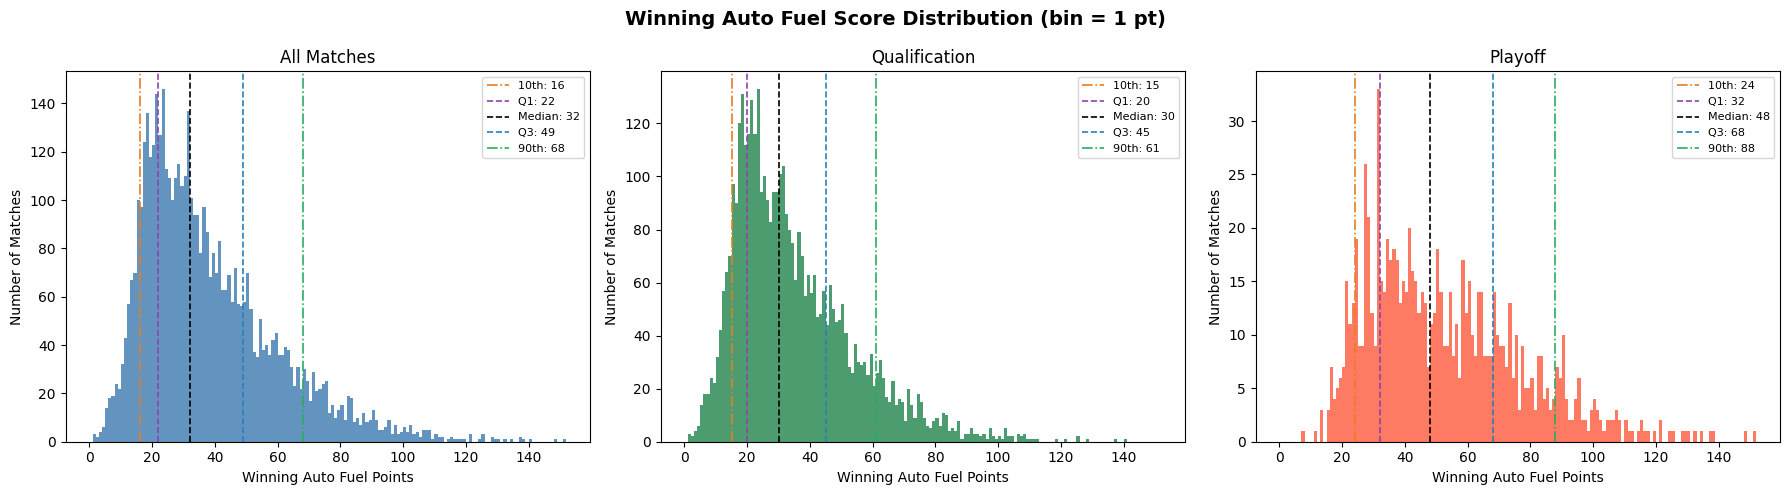

In [8]:
max_score = int(decisive["winning_auto_score"].max()) + 1
bins = np.arange(0, max_score + 1, 1)  # bin width of 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Winning Auto Fuel Score Distribution (bin = 1 pt)", fontsize=14, fontweight="bold")

subsets = [
    (decisive,                                      "All Matches",   "steelblue"),
    (decisive[decisive["match_type"] == "qual"],    "Qualification", "seagreen"),
    (decisive[decisive["match_type"] == "playoff"], "Playoff",       "tomato"),
]

ref_lines = [
    (10, "#e67e22", "-.", "10th"),
    (25, "#8e44ad", "--", "Q1"),
    (50, "black",   "--", "Median"),
    (75, "#2980b9", "--", "Q3"),
    (90, "#27ae60", "-.", "90th"),
]

for ax, (data, title, color) in zip(axes, subsets):
    ax.hist(data["winning_auto_score"], bins=bins, color=color, edgecolor="none", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Winning Auto Fuel Points")
    ax.set_ylabel("Number of Matches")
    for pct, lc, ls, lbl in ref_lines:
        val = np.percentile(data["winning_auto_score"], pct)
        ax.axvline(val, color=lc, linestyle=ls, linewidth=1.2, label=f"{lbl}: {val:.0f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

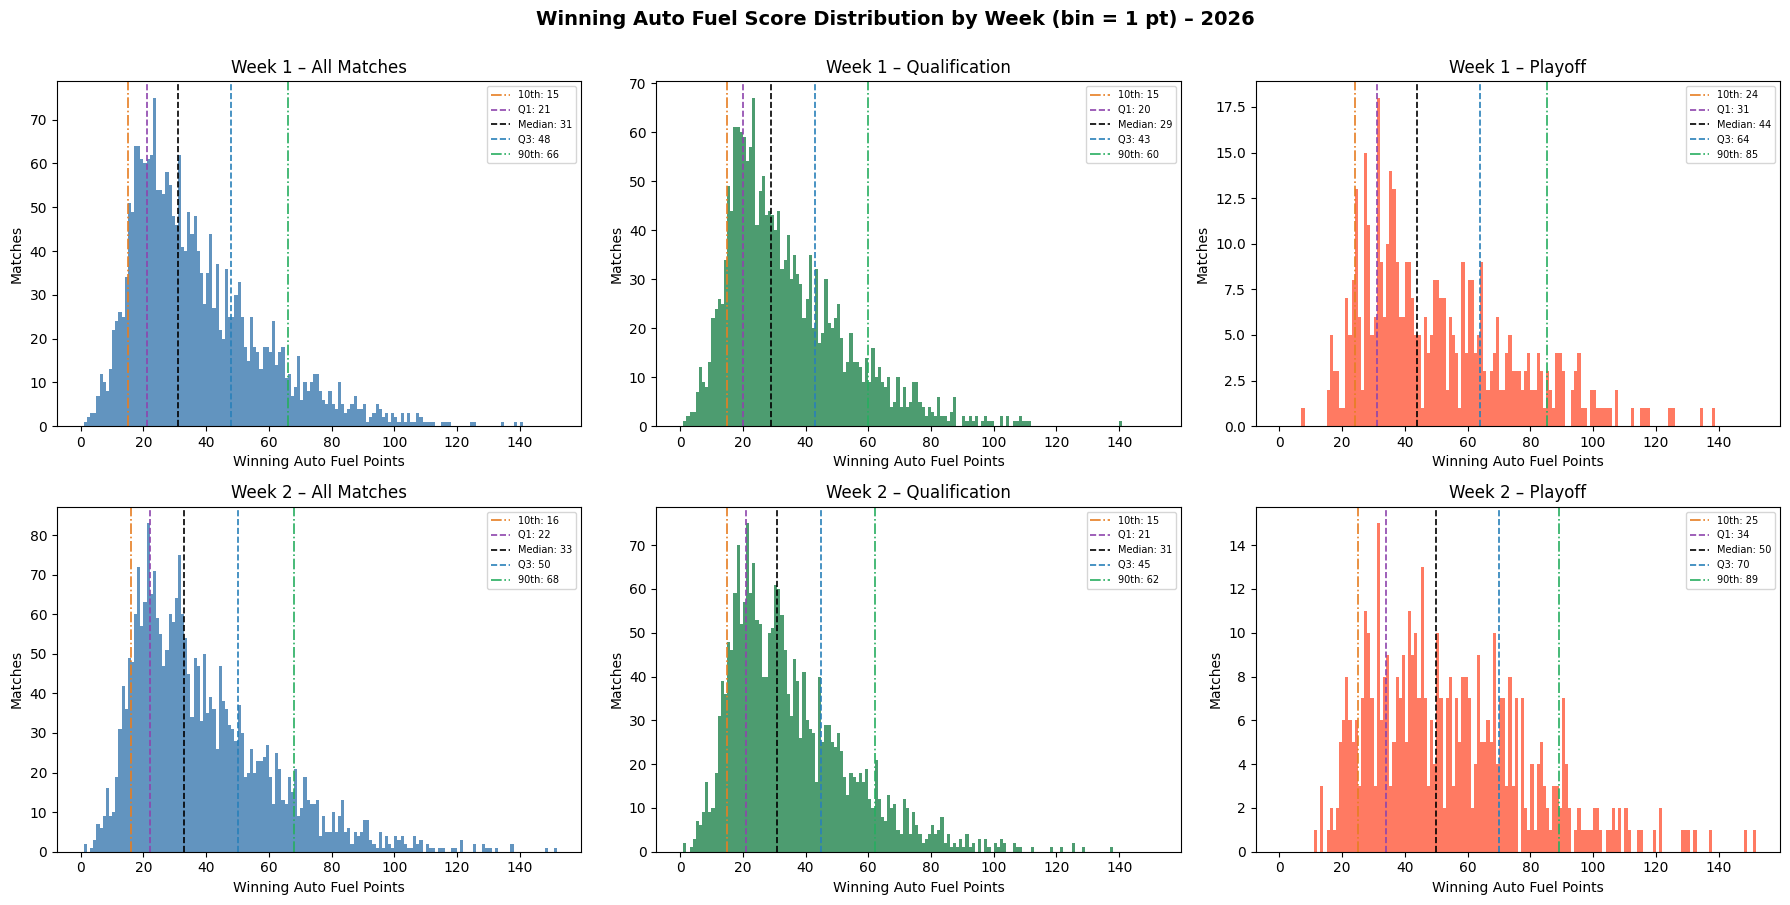

In [9]:
weeks = sorted(decisive["week"].unique())
n_weeks = len(weeks)

match_subsets = [
    ("All Matches",   None,      "steelblue"),
    ("Qualification", "qual",    "seagreen"),
    ("Playoff",       "playoff", "tomato"),
]

fig, axes = plt.subplots(n_weeks, 3, figsize=(18, 4.5 * n_weeks), squeeze=False)
fig.suptitle(f"Winning Auto Fuel Score Distribution by Week (bin = 1 pt) – {CURRENT_YEAR}",
             fontsize=14, fontweight="bold", y=1.0)

for row_i, w in enumerate(weeks):
    week_all = decisive[decisive["week"] == w]
    for col_j, (label, mtype, color) in enumerate(match_subsets):
        ax = axes[row_i][col_j]
        data = week_all if mtype is None else week_all[week_all["match_type"] == mtype]
        if data.empty:
            ax.set_title(f"{week_labels[w]} – {label} (no data)")
            ax.set_visible(True)
            continue
        ax.hist(data["winning_auto_score"], bins=bins, color=color, edgecolor="none", alpha=0.85)
        ax.set_title(f"{week_labels[w]} – {label}")
        ax.set_xlabel("Winning Auto Fuel Points")
        ax.set_ylabel("Matches")
        for pct, lc, ls, lbl in ref_lines:
            val = np.percentile(data["winning_auto_score"], pct)
            ax.axvline(val, color=lc, linestyle=ls, linewidth=1.2, label=f"{lbl}: {val:.0f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Step 5 – Auto Fuel Win Margin Distribution (10% Percentiles)

The win margin is the difference in auto fuel points between the alliance that won auto fuel
and the alliance that lost. Shown overall and broken down by week. (Tower points are excluded.)

In [10]:
# Calculate auto fuel win margin (always positive: winner - loser)
decisive["auto_margin"] = (decisive[["red_auto_fuel_points", "blue_auto_fuel_points"]].max(axis=1)
                         - decisive[["red_auto_fuel_points", "blue_auto_fuel_points"]].min(axis=1))

# Overall percentile table
all_margin = percentile_table(decisive["auto_margin"], "All Matches")
quals_margin = percentile_table(
    decisive.loc[decisive["match_type"] == "qual", "auto_margin"], "Qualification"
)
playoffs_margin = percentile_table(
    decisive.loc[decisive["match_type"] == "playoff", "auto_margin"], "Playoff"
)
margin_df = all_margin.merge(quals_margin, on="Percentile").merge(playoffs_margin, on="Percentile")

print("Auto Fuel Win Margin Distribution – Overall (10% Percentiles)\n")
print(margin_df.to_string(index=False))

# Per-week percentile table
print("\n\nAuto Fuel Win Margin Distribution – By Week (10% Percentiles)\n")
weekly_margin_df = pd.DataFrame({"Percentile": [f"{p}%" for p in percentiles]})
for w in sorted(decisive["week"].unique()):
    week_data = decisive[decisive["week"] == w]
    weekly_margin_df = weekly_margin_df.merge(
        percentile_table(week_data["auto_margin"], week_labels[w]),
        on="Percentile",
    )

print(weekly_margin_df.to_string(index=False))

Auto Fuel Win Margin Distribution – Overall (10% Percentiles)

Percentile All Matches Qualification Playoff
        0%         1.0           1.0     1.0
       10%         3.0           2.0     3.0
       20%         5.0           5.0     7.0
       30%         8.0           7.0     9.0
       40%        10.0          10.0    13.0
       50%        14.0          13.0    16.0
       60%        18.0          17.0    21.0
       70%        23.0          22.0    29.0
       80%        31.0          29.0    38.6
       90%        44.0          41.0    51.0
      100%       131.0         127.0   131.0


Auto Fuel Win Margin Distribution – By Week (10% Percentiles)

Percentile Week 1 Week 2
        0%    1.0    1.0
       10%    3.0    3.0
       20%    5.0    5.0
       30%    8.0    7.0
       40%   11.0   10.0
       50%   14.0   13.0
       60%   18.0   17.0
       70%   23.0   23.0
       80%   31.8   30.0
       90%   44.0   43.0
      100%  127.0  131.0


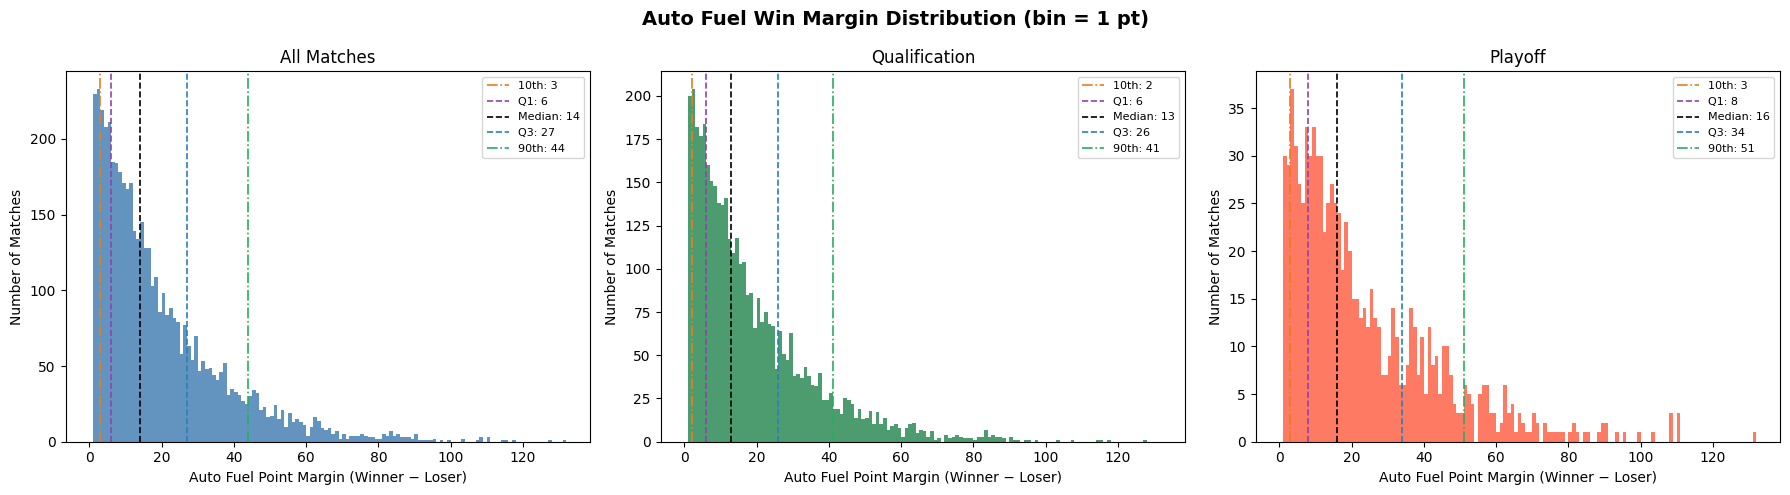

In [11]:
max_margin = int(decisive["auto_margin"].max()) + 1
bins_margin = np.arange(0, max_margin + 1, 1)  # bin width of 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Auto Fuel Win Margin Distribution (bin = 1 pt)", fontsize=14, fontweight="bold")

subsets = [
    (decisive,                                      "All Matches",   "steelblue"),
    (decisive[decisive["match_type"] == "qual"],    "Qualification", "seagreen"),
    (decisive[decisive["match_type"] == "playoff"], "Playoff",       "tomato"),
]

ref_lines = [
    (10, "#e67e22", "-.", "10th"),
    (25, "#8e44ad", "--", "Q1"),
    (50, "black",   "--", "Median"),
    (75, "#2980b9", "--", "Q3"),
    (90, "#27ae60", "-.", "90th"),
]

for ax, (data, title, color) in zip(axes, subsets):
    ax.hist(data["auto_margin"], bins=bins_margin, color=color, edgecolor="none", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Auto Fuel Point Margin (Winner − Loser)")
    ax.set_ylabel("Number of Matches")
    for pct, lc, ls, lbl in ref_lines:
        val = np.percentile(data["auto_margin"], pct)
        ax.axvline(val, color=lc, linestyle=ls, linewidth=1.2, label=f"{lbl}: {val:.0f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

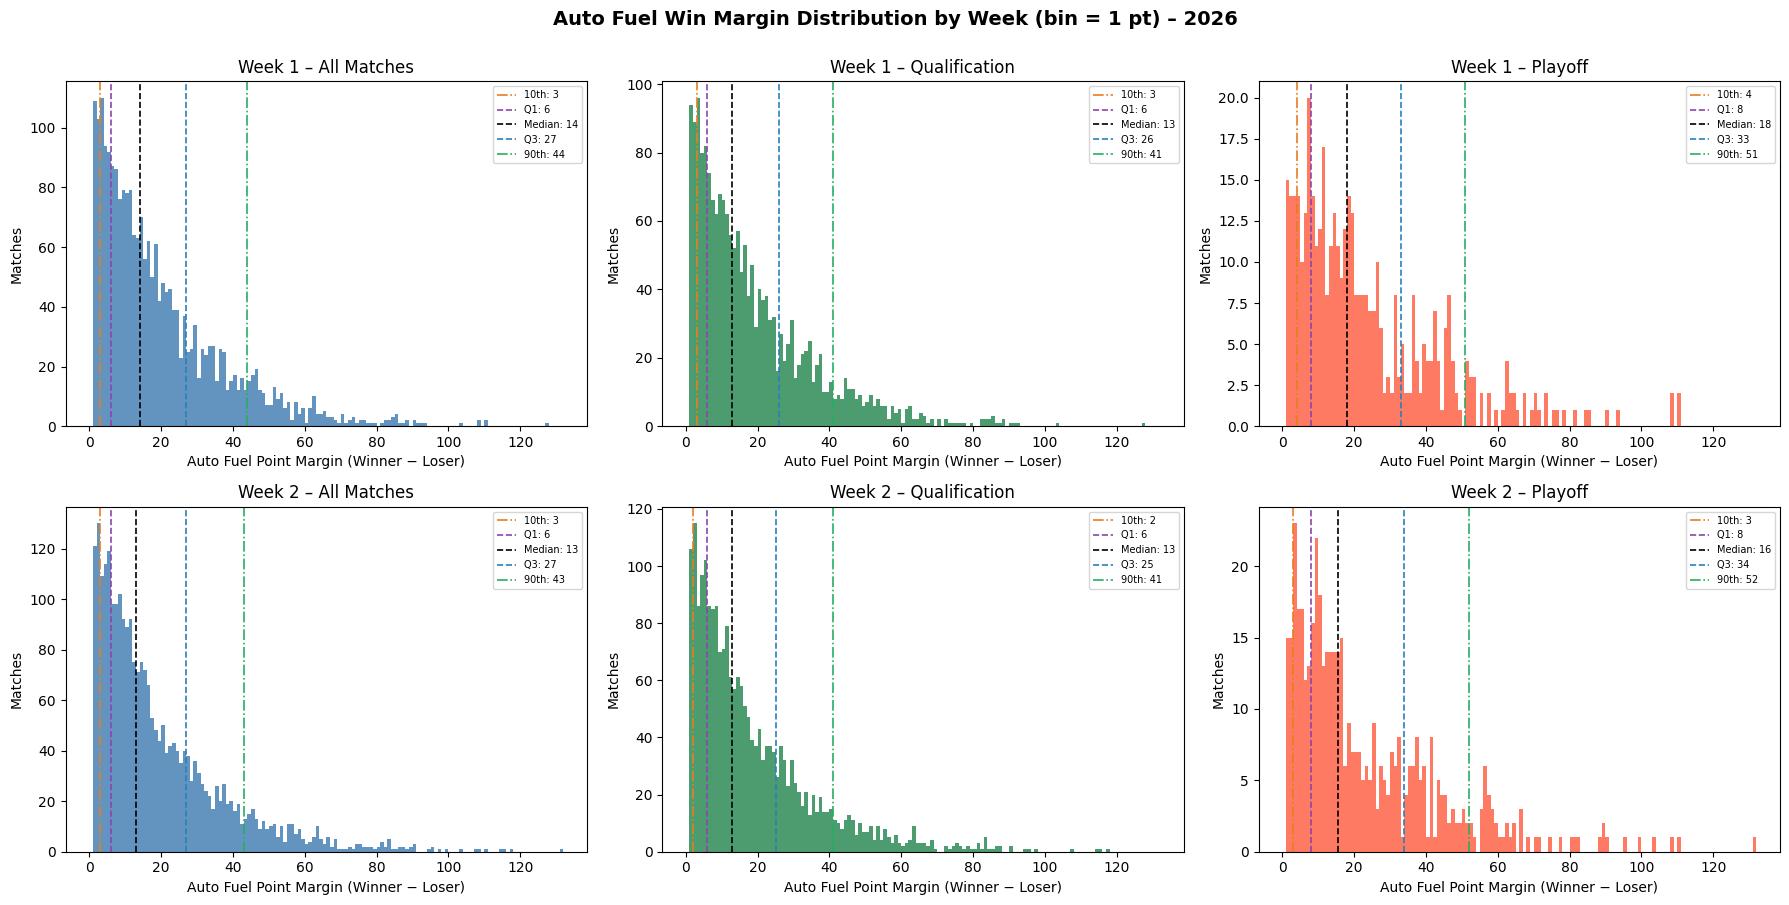

In [12]:
fig, axes = plt.subplots(n_weeks, 3, figsize=(18, 4.5 * n_weeks), squeeze=False)
fig.suptitle(f"Auto Fuel Win Margin Distribution by Week (bin = 1 pt) – {CURRENT_YEAR}",
             fontsize=14, fontweight="bold", y=1.0)

for row_i, w in enumerate(weeks):
    week_all = decisive[decisive["week"] == w]
    for col_j, (label, mtype, color) in enumerate(match_subsets):
        ax = axes[row_i][col_j]
        data = week_all if mtype is None else week_all[week_all["match_type"] == mtype]
        if data.empty:
            ax.set_title(f"{week_labels[w]} – {label} (no data)")
            ax.set_visible(True)
            continue
        ax.hist(data["auto_margin"], bins=bins_margin, color=color, edgecolor="none", alpha=0.85)
        ax.set_title(f"{week_labels[w]} – {label}")
        ax.set_xlabel("Auto Fuel Point Margin (Winner − Loser)")
        ax.set_ylabel("Matches")
        for pct, lc, ls, lbl in ref_lines:
            val = np.percentile(data["auto_margin"], pct)
            ax.axvline(val, color=lc, linestyle=ls, linewidth=1.2, label=f"{lbl}: {val:.0f}")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
def print_100th_percentile_matches(decisive_df, score_col, label):
    max_val = decisive_df[score_col].max()
    matches = decisive_df[decisive_df[score_col] == max_val][
        ["match_key", "event_key", "week", "red_auto_fuel_points", "blue_auto_fuel_points", "winning_alliance"]
    ].copy()
    print(f"── 100th Percentile: {label} = {max_val:.0f} ─────────────────")
    for _, row in matches.iterrows():
        winning_auto_alliance = "Red" if row["red_auto_fuel_points"] > row["blue_auto_fuel_points"] else "Blue"
        print(f"  Match:    {row['match_key']}")
        print(f"  Event:    {row['event_key']}")
        print(f"  Week:     {week_labels[row['week']]}")
        print(f"  Alliance that scored {max_val:.0f}: {winning_auto_alliance}")
        print(f"  Red auto fuel pts: {row['red_auto_fuel_points']}   Blue auto fuel pts: {row['blue_auto_fuel_points']}")
        print(f"  Match winner: {row['winning_alliance'].capitalize()}")
        print()

# 100th percentile – winning auto fuel score
print_100th_percentile_matches(decisive, "winning_auto_score", "Winning Auto Fuel Score")

# 100th percentile – auto fuel win margin
print_100th_percentile_matches(decisive, "auto_margin", "Auto Fuel Win Margin")

── 100th Percentile: Winning Auto Fuel Score = 151 ─────────────────
  Match:    2026casnv_sf7m1
  Event:    2026casnv
  Alliance that scored 151: Red
  Red auto fuel pts: 151   Blue auto fuel pts: 43
  Match winner: Red

── 100th Percentile: Auto Fuel Win Margin = 131 ─────────────────
  Match:    2026casnv_sf1m1
  Event:    2026casnv
  Alliance that scored 131: Red
  Red auto fuel pts: 148   Blue auto fuel pts: 17
  Match winner: Red

